In [1]:
import matplotlib.pyplot as plt
import numpy as np, pandas as pd

from tqdm import tqdm

from mcbif import MultiscaleClusteringBifiltration as MCbiF
from mcbif import load_results, save_results

import sys
sys.path.append('..')

from common import sampling
from common.entropy import nce_ttprime
from common import sankey_crossing

In [2]:
# We set a global configuration for matplotlib to obtain well-readable plots
SMALL_SIZE = 18
MEDIUM_SIZE = 18
BIGGER_SIZE = 18

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

# Sample trajectories and compute features

In [3]:
def compute_trajectory(partitions, id, mcbif_method="nerve"):

    # save trajectory
    np.save(f"data/raw/{id}_partitions.npy", partitions)

    # compute nce
    nce = nce_ttprime(partitions)
    np.save(f"data/raw/{id}_nce.npy", nce)

    # compute mcbif
    mcbif = MCbiF(max_dim=2, method=mcbif_method)   
    mcbif.load_data(partitions=partitions)
    mcbif.compute_all_measures(file_path=f"data/raw/{id}_mcbif.pkl", landscape_k_max=3, tqdm_disable=True)

    # compute Sankey
    sankey_data = sankey_crossing.compute_sankey(partitions)
    sankey_result = sankey_crossing.compute_omics_sankey(sankey_data)
    save_results(sankey_result, f"data/raw/{id}_sankey.pkl")

    return nce, mcbif, sankey_result
    

In [ ]:
def sample_N_M_results(N,M, seed=42, n_samples=1000, skip=0, mcbif_method="nerve"):

    # generate all partitions of the set
    partitions_result = sampling.all_partitions(range(N))

    # compute number of partitions per size (excluding the two trivial partitions of size 1 and N)
    n_partitioncs_per_size = np.array([len(partitions_result[c]) for c in range(1,N-1)])

    # initialise rng
    rng = np.random.default_rng(seed)

    # iterate for n_samples
    for i in tqdm(range(n_samples)):

        # sample a coarsening trajectory
        partitions = sampling.sample_trajectory(n_partitioncs_per_size,N,M,partitions_result,rng)

        if i < skip:    
            continue
        else:
            # compute results
            compute_trajectory(partitions, id=f"N{N}_M{M}/N{N}_M{M}_id{i}", mcbif_method=mcbif_method)

In [ ]:
# sample sequences of partitions for N=5 and M=20, and compute the corresponding features
sample_N_M_results(5,20,seed=42,n_samples=20000)

In [ ]:
# sample sequences of partitions for N=10 and M=20, and compute the corresponding features
sample_N_M_results(10,20,seed=42,n_samples=20000)

# Extract features

In [2]:
def extract_features(N, M, n_samples):
    """Extract features and labels for the regression task from the raw data."""

    nce = []
    mcbif = []
    sankey = []
    partitions = []

    # load data
    for i in range(n_samples):
        nce.append(np.load(f"data/raw/N{N}_M{M}/N{N}_M{M}_id{i}_nce.npy"))
        mcbif.append(load_results(f"data/raw/N{N}_M{M}/N{N}_M{M}_id{i}_mcbif.pkl"))
        sankey.append(load_results(f"data/raw/N{N}_M{M}/N{N}_M{M}_id{i}_sankey.pkl"))
        partitions.append(np.load(f"data/raw/N{N}_M{M}/N{N}_M{M}_id{i}_partitions.npy"))

    # extract Hilbert functions
    hf0 = [mcbif[i]["betti_0_rank"] for i in range(n_samples)]
    hf1 = [mcbif[i]["betti_1_rank"] for i in range(n_samples)]

    # extract crossing number
    y = [
        (
            int(sankey[i]["Stage 2 Crossing"])
            if int(sankey[i]["Stage 2 Crossing"]) > 0
            else int(sankey[i]["Stage 1 Crossing"])
        )
        for i in range(n_samples)
    ]

    # save data
    np.save(f"data/N{N}_M{M}_y_crossing.npy", np.array(y))
    np.save(f"results/features/N{N}_M{M}_nce.npy", np.array(nce))
    np.save(f"results/features/N{N}_M{M}_hf0.npy", np.array(hf0))
    np.save(f"results/features/N{N}_M{M}_hf1.npy", np.array(hf1))
    np.save(f"data/N{N}_M{M}_partitions.npy", np.array(partitions))

    return (
        np.array(y),
        np.array(nce),
        np.array(hf0),
        np.array(hf1),
        np.array(partitions),
    )

In [ ]:
# extract features and labels for the regression task for N=5 and M=20
y, nce, u, hf0, hf1, partitions = extract_features(5,20,20000)

In [ ]:
# extract features and labels for the regression task for N=10 and M=20
y, nce, u, hf0, hf1, partitions = extract_features(10,20,20000)

# Check mathematical statements about Sankey

Off-diagonal HF1 is indeed a lower bound for crossing number.

In [52]:
np.sum((y - np.diagonal(hf1,offset=1, axis1=1, axis2=2).sum(axis=1)) < 0)

np.int64(0)

In [45]:
np.sum((y - np.diagonal(hf1,offset=1, axis1=1, axis2=2).sum(axis=1))[y>0] < 0)

np.int64(0)

# Correlations

In [9]:
def mean_features_df(N,M, exclude_zeros=True):

    # load data
    y = np.load(f"data/N{N}_M{M}_y_crossing.npy")
    nce = np.load(f"results/features/N{N}_M{M}_nce.npy")
    hf0 = np.load(f"results/features/N{N}_M{M}_hf0.npy")
    hf1 = np.load(f"results/features/N{N}_M{M}_hf1.npy")
    ari = np.load(f"results/features/N{N}_M{M}_ari.npy")
    mod = np.load(f"results/features/N{N}_M{M}_mod.npy")

    # Compute outlier mask
    non_outliers = (y <= np.percentile(y, 99.9)) * (y >= np.percentile(y, 0.1))

    # Exclude sequences with zero crossings if specified
    if exclude_zeros:
        non_outliers = non_outliers * (y != 0)

    # Remove outliers
    y = y[non_outliers]
    nce = nce[non_outliers]
    hf0 = hf0[non_outliers]
    hf1 = hf1[non_outliers]
    ari = ari[non_outliers]
    mod = mod[non_outliers]

    n_samples = y.shape[0]    

    normalisation = M * (M-1) / 2

    # compute mean nce
    nce_m = np.array([np.triu(nce[i].T).sum() / normalisation for i in range(n_samples)])

    # compute mean vi
    vi_m = np.array([nce[i].sum() / normalisation for i in range(n_samples)])

    # compute mean ari
    ari_m = np.array([ari[i].sum() / normalisation for i in range(n_samples)])

    # compute mean mpo
    mod_m = np.array([mod[i].sum() / normalisation for i in range(n_samples)])

    # compute mean hf1
    hf1_m = np.array([np.triu(hf1[i]).sum() / normalisation for i in range(n_samples)])

    # compute mean hf0
    hf0_m = np.array([np.triu(hf0[i]).sum() / normalisation for i in range(n_samples)])

    # compute mean persistent hiearchy
    h_m = 1 - np.array([np.triu(hf0[i] / np.diag(hf0[i]),k=1).sum() / normalisation for i in range(n_samples)])

    # create dataframe
    df = pd.DataFrame({"y" : y, #"nce_m" : nce_m, 
                       "c0_m" : h_m, "c1_m" : hf1_m,  #"hf0_m" : hf0_m
                       "vi_m" : vi_m, 
                       "ari_m" : ari_m, 
                       "mod_m" : mod_m,
                    })

    return df

In [11]:
df_n5 = mean_features_df(5,20, exclude_zeros=True)
df_n5.corr("pearson").style.background_gradient(cmap='coolwarm', axis=None)

,y,c0_m,c1_m,vi_m,ari_m,mod_m
y,1.000000,0.270016,0.467556,0.197019,-0.222727,-0.124283
c0_m,0.270016,1.000000,0.517569,-0.318817,-0.167521,0.447519
c1_m,0.467556,0.517569,1.000000,-0.117042,-0.174409,0.143488
vi_m,0.197019,-0.318817,-0.117042,1.000000,-0.567289,-0.749205
ari_m,-0.222727,-0.167521,-0.174409,-0.567289,1.000000,0.632662
mod_m,-0.124283,0.447519,0.143488,-0.749205,0.632662,1.000000


In [12]:
import seaborn as sns

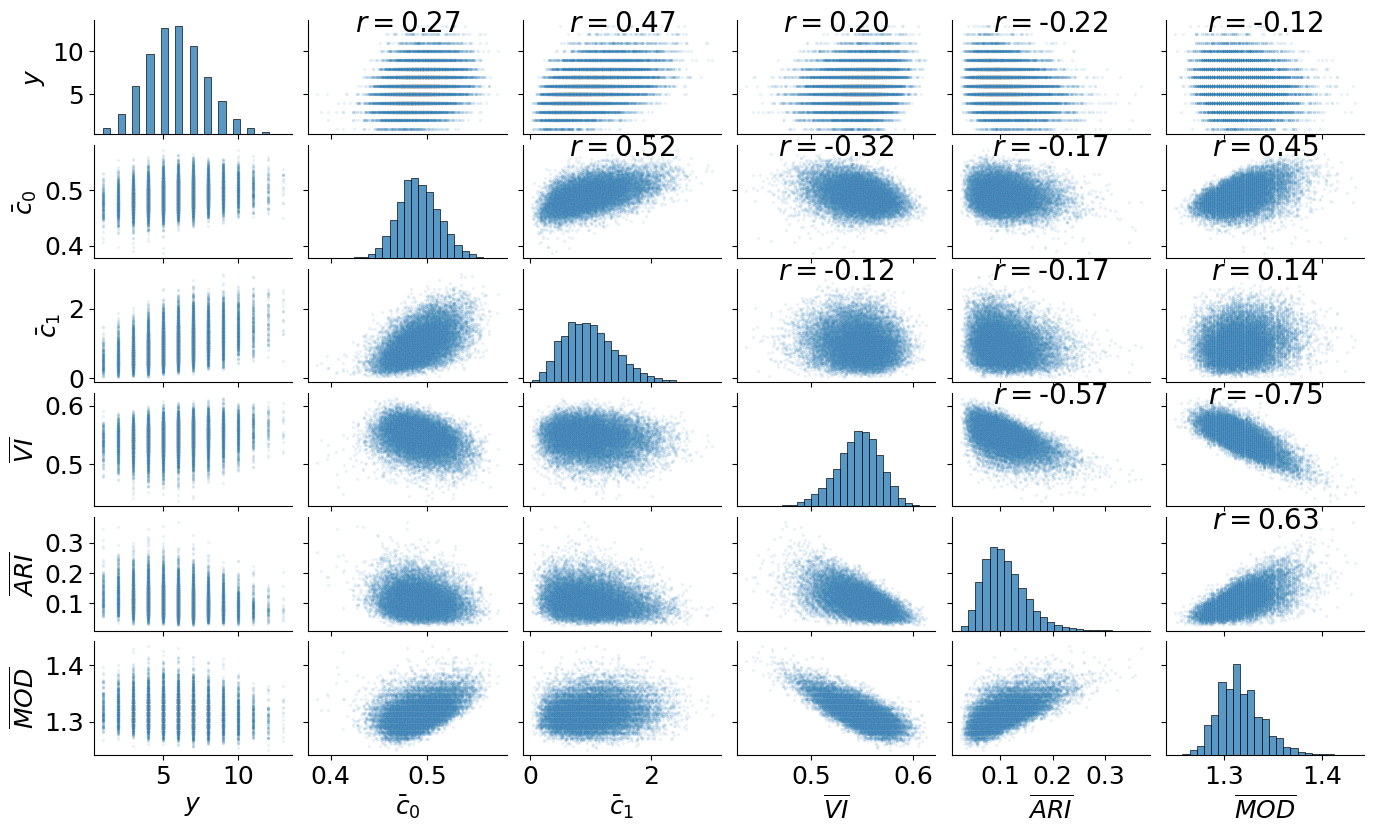

In [13]:
labels = [r"$y$", r"$\bar c_0$", r"$\bar c_1$", r"$\overline{VI}$", r"$\overline{ARI}$", r"$\overline{MOD}$",]

df_n5.columns = labels

# Annotate Pearson correlation coefficients on the upper triangular part of the pairplot
def annotate_upper_triangle(x, y, **kwargs):
    if x.name != y.name:  # Avoid diagonal elements
        r = np.corrcoef(x, y)[0, 1]
        ax = plt.gca()
        ax.annotate(f"$r=${r:.2f}", xy=(0.5, 0.9), xycoords=ax.transAxes, ha='center', fontsize=20)

g = sns.pairplot(df_n5, plot_kws={'alpha':0.1, 's':5}, diag_kws= {'common_bins' :False, 'bins':25}
                ).map_upper(annotate_upper_triangle)

# Adjust the histograms to have the same height
# g.diag_axes[0].set_ylim(0, 10000)  # Set y-limit for the second histogram:

# Save the plot as a smaller PDF
plt.gcf().set_size_inches(14, 8)  # Adjust the figure size
plt.savefig('figures/pairplot_n5.png', bbox_inches='tight')
plt.show()

In [14]:
df_n10 = mean_features_df(10,20, exclude_zeros=True)
df_n10.corr("pearson").style.background_gradient(cmap='coolwarm', axis=None)

,y,c0_m,c1_m,vi_m,ari_m,mod_m
y,1.000000,0.296657,0.469209,0.060057,-0.232432,-0.015883
c0_m,0.296657,1.000000,0.428207,-0.484387,-0.073926,0.655223
c1_m,0.469209,0.428207,1.000000,-0.342547,-0.157337,0.268931
vi_m,0.060057,-0.484387,-0.342547,1.000000,-0.378263,-0.803020
ari_m,-0.232432,-0.073926,-0.157337,-0.378263,1.000000,0.476298
mod_m,-0.015883,0.655223,0.268931,-0.803020,0.476298,1.000000


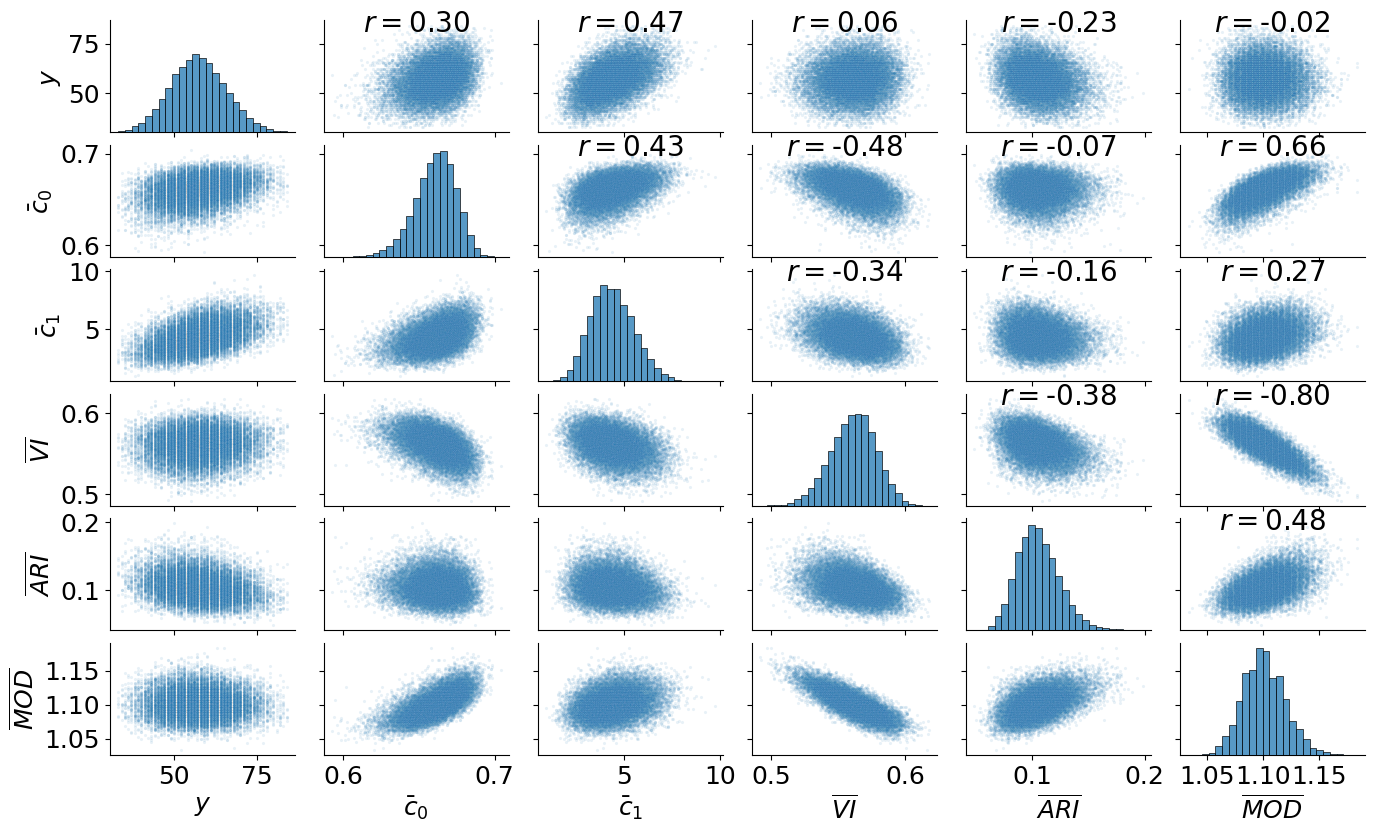

In [15]:
df_n10.columns = labels

# Annotate Pearson correlation coefficients on the upper triangular part of the pairplot
def annotate_upper_triangle(x, y, **kwargs):
    if x.name != y.name:  # Avoid diagonal elements
        r = np.corrcoef(x, y)[0, 1]
        ax = plt.gca()
        ax.annotate(f"$r=${r:.2f}", xy=(0.5, 0.9), xycoords=ax.transAxes, ha='center', fontsize=20)


sns.pairplot(df_n10, plot_kws={'alpha':0.1, 's':5}, diag_kws= {'common_bins' :False, 'bins':25}).map_upper(annotate_upper_triangle)

# Save the plot as a smaller PDF
plt.gcf().set_size_inches(14, 8)  # Adjust the figure size
plt.savefig('figures/pairplot_n10.png', bbox_inches='tight')
plt.show()